## Metódo númerico para determinar el valor de un polinommio de legendre de forma iterativa


Coeficientes bn:
b_0 = 0.4905
b_1 = 1.9429
b_2 = -3.8571
b_3 = 0.3111
b_4 = -1.2156
b_5 = -0.2540
b_6 = -0.1177


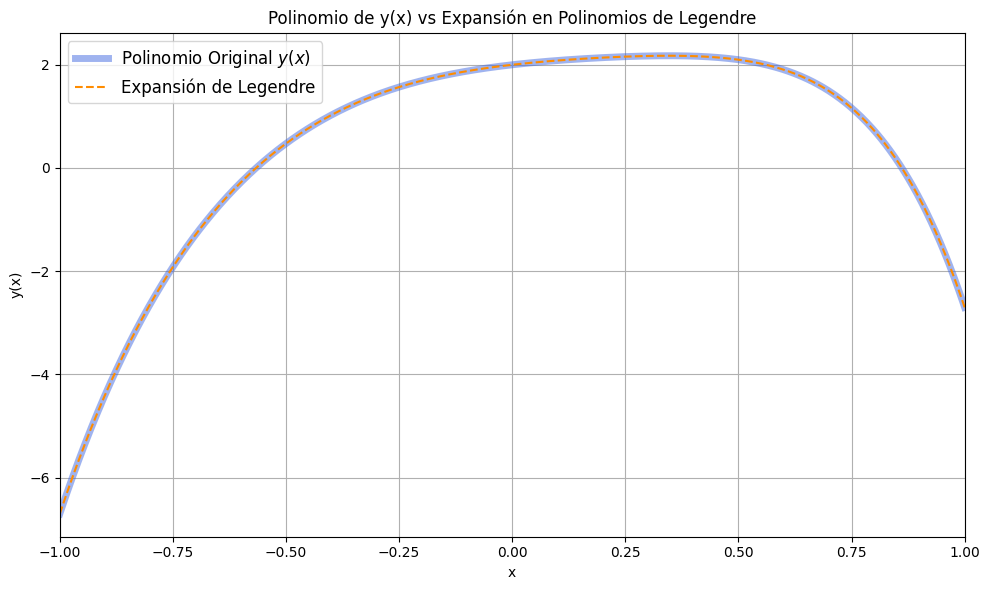

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson

def polinomios_legendre(n_max, x):

    # Crearemos primero un array donde se guerden los polinomios de Legendre. 
    P = np.zeros((n_max + 1, len(x))) 

    # Condicion para el primer polinomio de Legendre
    P[0, :] = 1

    if n_max > 0: 
        P[1, :] = x

    for n in range(2, n_max + 1):
        P[n, :] = ((2 * n - 1) * x * P[n-1, :] - (n - 1) * P[n-2, :]) / n
    
    return P 

def coeficientes_legendre(func, x, Pn, n_max):
    
    #Creamps un array para guardar los coeficientes de Legendre
    bn = np.zeros(n_max + 1)

    #Reaizamos proceso iterativo para calcular los coeficientes de Legendre utilizando la relacion de ortogonalidad.
    for n in range(n_max + 1):
        # Relación de ortogonalidad
        integrando = func * Pn[n, :]
        # Aproximación númerica por método de Simpson
        val_integrando = simpson(integrando, x = x)
        # Constante de normalización
        bn[n] = (2 * n + 1) / 2 * val_integrando

    return bn


# Coeficientes a evaluar
a_n = [2, 1, -2, 3, -3, -2, -1.7]

# Grados de polinomios requeridos para la representación
N_max = len(a_n) - 1

# Definimos el intervalo |x| <= 1 para relación de ortogonalidad
x = np.linspace(-1, 1, 1000)

# Construimos el polinomio original y(x) = a0 + a1*x + a2*x^2 + ... + aN*x^N
y_x = np.zeros_like(x)
for i, coef in enumerate(a_n):
    y_x += coef * (x ** i)

# Polinomios de Legendre en nuestro intervalo x
Pn = polinomios_legendre(N_max, x)

# Cálculo de coeficientes bn
b_n = coeficientes_legendre(y_x, x, Pn, N_max)

print("Coeficientes bn:")
for i, b in enumerate(b_n):
    print(f"b_{i} = {b:.4f}")

# Construimos y(x) usando nuestra serie finita de Legendre
y_legendre = np.zeros_like(x)
for n in range(N_max + 1):
    y_legendre += b_n[n] * Pn[n, :]

# Graficamos ambas funciones una encima de la otra
plt.figure(figsize=(10, 6))
plt.plot(x, y_x, label='Polinomio Original $y(x)$', linewidth=5, color='royalblue', alpha=0.5)
plt.plot(x, y_legendre, label='Expansión de Legendre', linestyle='--', color='darkorange')
plt.title('Polinomio de y(x) vs Expansión en Polinomios de Legendre')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.xlim(-1, 1)
plt.grid(True)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()